In [1]:
import numpy as np 
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols
import statsmodels.api as sm

### One-way ANOVA
Let say we have a groups with r observations. So, we have N= ar observation in total. Let denote overall mean as $\bar{Y}$

- Total sum of squares $SST = \sum_{i=1}^{N} (Y_i - \bar{Y})^2$

- Sum of squares treatment $SSA = r (\bar{Y}_i - \bar{Y})^2$

- Sum of squares error $SSE = SST - SSA $

- Mean squares treatment $MSA = \frac{SSA}{a-1}$ where a is number of groups

- Mean squares error $MSE = \frac{SSE}{N-a}$

Then, test statistic ($F$-statistic)  is:
$$ F = \frac{MSA}{MSE}  $$


#### Example
A researcher for an automobile safety institute was interested in determining whether or not the distance that it takes to stop a car going 60 miles per hour depends on the brand of the tire. The researcher measured the stopping distance (in feet) of ten randomly selected cars for each of five different brands. So that he and his assistants would remain blinded, the researcher arbitrarily labeled the brands of the tires as Brand1, Brand2, Brand3, Brand4, and Brand5. Do the data provide enough evidence to conclude that at least one of the brands is different from the others with respect to stopping distance?

Null Hypothesis $H_0: \mu_1 = \mu_2 = \mu_3 = \mu_4 = \mu_5$

In [2]:
brand1 = [194, 184, 189, 189, 188, 186, 195, 186, 183, 188]
brand2 = [189, 204, 190, 190, 189, 207, 203, 193, 181, 206]
brand3 = [185, 183, 186, 183, 179, 191, 188, 196, 189, 194]
brand4 = [183, 193, 184, 186, 194, 199, 196, 188, 193, 196]
brand5 = [195, 197, 194, 202, 200, 211, 203, 206, 202, 195]

In [ ]:
F_stat, p_value = st.f_oneway(brand1, brand2, brand3, brand4, brand5)

# Let calculate the values in ANOVA table
all_data = np.concatenate([brand1, brand2, brand3, brand4, brand5])
groups = [brand1, brand2, brand3, brand4, brand5]


a = len(groups)  
r = len(brand1) # since we have the same number of observation for each group, we take one of them
N = len(all_data) # or a*r

grand_mean = np.mean(all_data)

# Sum of Squares
SSA = sum(len(g) * (np.mean(g) - grand_mean) ** 2 for g in groups)

SSE = sum(sum((x - np.mean(g)) ** 2 for x in g) for g in groups)

# Degrees of freedom
df_A = a - 1
df_E = N - a # or a * (r-1)

# Mean Squares
MSA = SSA / df_A
MSE = SSE / df_E

# F-statistic
F_calculated = MSA / MSE
p_calculated = st.f.sf(F_calculated, df_A, df_E)


print("Compare calculation from scratch and scipy")
print("Scipy:", F_stat, p_value)
print("Calculated:", F_calculated, p_calculated)


#ANOVA table
anova_table = pd.DataFrame({
    "Source": ["Between Groups (Factor)", "Within Groups (Error)", "Total"],
    "SS": [SSA, SSE, SSA + SSE],
    "DF": [df_A, df_E, N - 1],
    "MS": [MSA, MSE, None],
    "F": [F_calculated, None, None],
    "p": [p_calculated, None, None]
})

print(anova_table)


Compare calculation from scratch and scipy
Scipy: 7.953601733164834 6.144035762630377e-05
Calculated: 7.953601733164834 6.144035762630377e-05
                    Source      SS  DF          MS         F         p
0  Between Groups (Factor)  1174.8   4  293.700000  7.953602  0.000061
1    Within Groups (Error)  1661.7  45   36.926667       NaN       NaN
2                    Total  2836.5  49         NaN       NaN       NaN


### Analyze Residuals

           sum_sq    df         F    PR(>F)
C(brands)  1174.8   4.0  7.953602  0.000061
Residual   1661.7  45.0       NaN       NaN


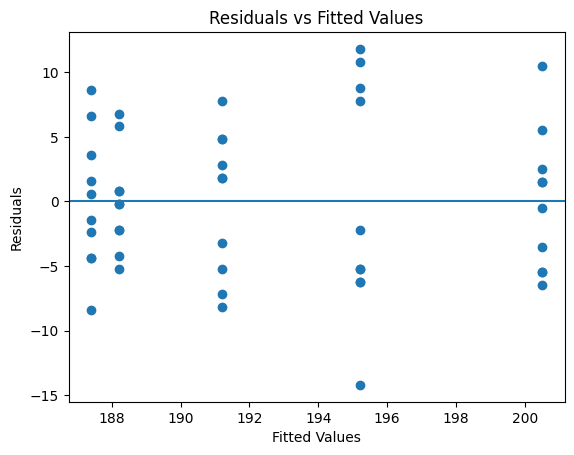

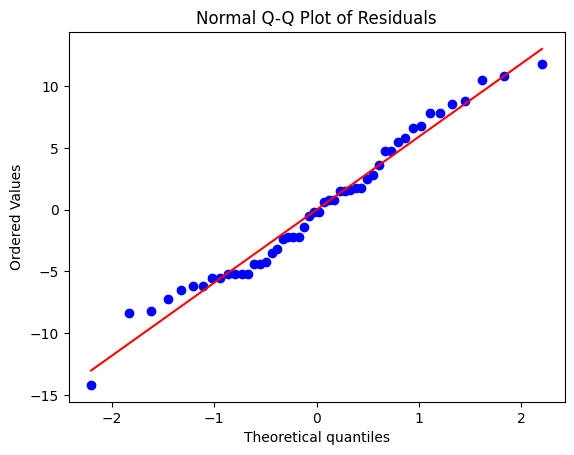

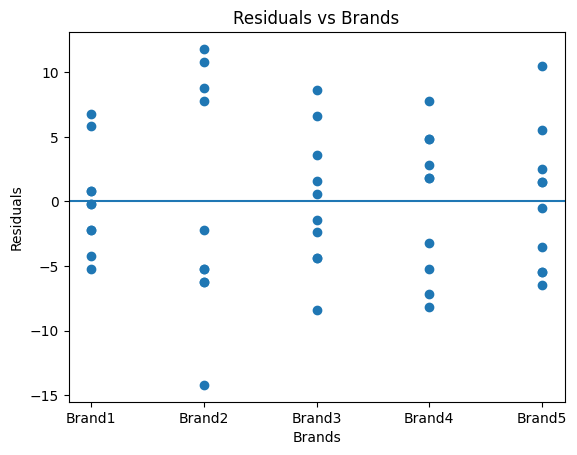

In [4]:
# Combine into a single dataframe
data = brand1 + brand2 + brand3 + brand4 + brand5
brands = ['Brand1']*10 + ['Brand2']*10 + ['Brand3']*10 + ['Brand4']*10 + ['Brand5']*10

df = pd.DataFrame({
    'brands': brands,
    'result': data
})

# Fit the one-way ANOVA model
model = ols('result ~ C(brands)', data=df).fit()

# ANOVA table
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

# Residuals and fitted values
residuals = model.resid
fitted = model.fittedvalues


# Residuals vs Fitted Plot
plt.figure()
plt.scatter(fitted, residuals)
plt.axhline(0)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

# Normal Q-Q Plot
plt.figure()
st.probplot(residuals, dist="norm", plot=plt)
plt.title("Normal Q-Q Plot of Residuals")
plt.show()

# Residuals vs Dosage
plt.figure()
plt.scatter(df["brands"], residuals)
plt.axhline(0)
plt.xlabel("Brands")
plt.ylabel("Residuals")
plt.title("Residuals vs Brands")
plt.show()


## Example 2

In [5]:
diet1 = [12, 10, 13, 11, 12, 9]
diet2 = [18, 19, 18, 18, 19,19]
diet3 = [10, 12, 13, 16, 14, 13]
diet4 = [19, 20, 18, 19, 18, 19]

In [6]:
F_stat, p_value = st.f_oneway(diet1, diet2, diet3, diet4)

# Let calculate the values in ANOVA table
all_data = np.concatenate([diet1, diet2, diet3, diet4])
groups = [diet1, diet2, diet3, diet4]


a = len(groups)  
r = len(diet1)
N = len(all_data) # or a*r

grand_mean = np.mean(all_data)

# Sum of Squares 
SSA = sum(len(g) * (np.mean(g) - grand_mean) ** 2 for g in groups)

SSE = sum(sum((x - np.mean(g)) ** 2 for x in g) for g in groups)

# Degrees of freedom
df_A = a - 1
df_E = N - a # or a * (r-1)

# Mean Squares
MSA = SSA / df_A
MSE = SSE / df_E

# F-statistic
F_calculated = MSA / MSE
p_calculated = st.f.sf(F_calculated, df_A, df_E)


print("Compare calculation from scratch and scipy")
print("Scipy:", F_stat, p_value)
print("Calculated:", F_calculated, p_calculated)


#ANOVA table
anova_table = pd.DataFrame({
    "Source": ["Between Groups (Factor)", "Within Groups (Error)", "Total"],
    "SS": [SSA, SSE, SSA + SSE],
    "DF": [df_A, df_E, N - 1],
    "MS": [MSA, MSE, None],
    "F": [F_calculated, None, None],
    "p": [p_calculated, None, None]
})

print(anova_table)



Compare calculation from scratch and scipy
Scipy: 51.27172195892581 1.424434840151075e-09
Calculated: 51.27172195892574 1.4244348401510923e-09
                    Source          SS  DF         MS          F             p
0  Between Groups (Factor)  270.458333   3  90.152778  51.271722  1.424435e-09
1    Within Groups (Error)   35.166667  20   1.758333        NaN           NaN
2                    Total  305.625000  23        NaN        NaN           NaN


                  sum_sq    df          F        PR(>F)
C(diet_type)  270.458333   3.0  51.271722  1.424435e-09
Residual       35.166667  20.0        NaN           NaN


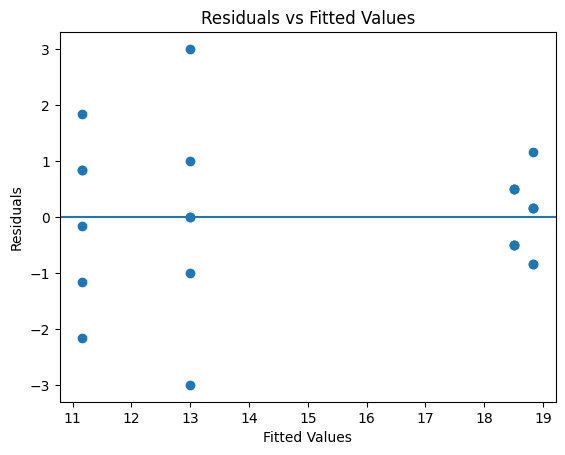

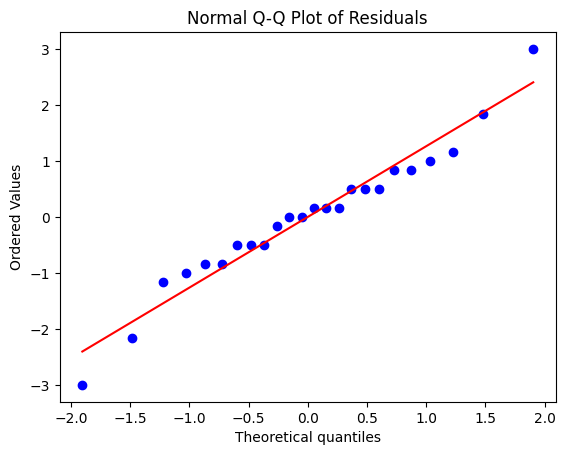

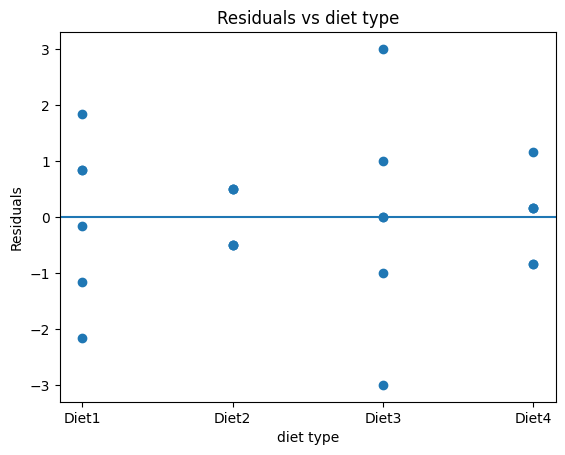

In [7]:
# Combine into a single dataframe
data = diet1 + diet2 + diet3 + diet4
diet_type = ['Diet1']*6 + ['Diet2']*6 + ['Diet3']*6 + ['Diet4']*6

df = pd.DataFrame({
    'diet_type': diet_type,
    'data': data
})

# Fit the one-way ANOVA model
model = ols('data ~ C(diet_type)', data=df).fit()

# ANOVA table
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

# Residuals and fitted values
residuals = model.resid
fitted = model.fittedvalues

# -----------------------------
# 1 Residuals vs Fitted Plot
# -----------------------------
plt.figure()
plt.scatter(fitted, residuals)
plt.axhline(0)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

# -----------------------------
# 2 Normal Q-Q Plot
# -----------------------------
plt.figure()
st.probplot(residuals, dist="norm", plot=plt)
plt.title("Normal Q-Q Plot of Residuals")
plt.show()

# -----------------------------
# 3 Residuals vs Dosage
# -----------------------------
plt.figure()
plt.scatter(df["diet_type"], residuals)
plt.axhline(0)
plt.xlabel("diet type")
plt.ylabel("Residuals")
plt.title("Residuals vs diet type")
plt.show()
